# Tables 2-4 
final version, selected from Tables S8-S10 respectively

In [1]:
import pandas as pd
import numpy as np
import sys
sys.path.append('/home/ls2543/python_packages')
import statsmodels.api as sm
from statsmodels.formula.api import ols
from tqdm import tqdm

df = pd.read_csv('C:/Users/86156/Desktop/NTJY/final_group_pos_doipmid_puby_deltadays_field_tsize_top5_before0_after1_coauthor_wc0_natindex_fpy_aca_exp_jif_EISSN.csv')
df = df[(df['DeltaDays'] > 0) & (df['DeltaDays'] <= 10000)].copy()


df['is_nature_index'] = df['is_nature_index'].fillna(2).astype('category')
df['JournalISSN'] = df['JournalISSN'].fillna("Unknown")
df['author_position'] = pd.Categorical(df['author_position'], categories=["first", "middle", "last"])
df['field'] = df['field'].astype('category')
df['is_top5'] = df['is_top5'].astype('category')
df['year_diff'] = abs(df['PubYear'] - df['awardYear'])

df_nature = df[df['is_nature_index'] == 1].copy()

df_nature['is_nature_index'] = df_nature['is_nature_index'].astype('category')  
df_nature['before_or_after'] = df_nature['before_or_after'].astype('category')  #

df_nature['is_nature_index'] = df_nature['is_nature_index'].cat.remove_unused_categories()
df_nature['before_or_after'] = df_nature['before_or_after'].cat.remove_unused_categories()
#df_nature

base_var = 'DeltaDays ~ C(if_winner) * C(before_or_after) + C(is_top5)'

model_specs_nature = [
    {'formula': base_var},
    {'formula': base_var + '+ year_diff'},
    {'formula': base_var + '+ teamsize'},
    {'formula': base_var + '+ teamsize + year_diff'},
    {'formula': base_var + '+ JIF'},
    {'formula': base_var + '+ JIF + ref_num'},
    {'formula': base_var + '+ academic_experience'},
    {'formula': base_var + '+ JIF + teamsize + year_diff + academic_experience + ref_num'},
    {'formula': base_var + '+ JIF + teamsize + year_diff + academic_experience + ref_num + C(author_position)'},
    {'formula': base_var + '+ JIF + teamsize + year_diff + academic_experience + ref_num + C(field)'},
    {'formula': base_var + '+ JIF + teamsize + year_diff + academic_experience + ref_num + C(JournalISSN)'},
    {'formula': base_var + '+ JIF + teamsize + year_diff + academic_experience + ref_num + C(author_position) + C(field)'},
    {'formula': base_var + '+ JIF + teamsize + year_diff + academic_experience + ref_num + C(author_position) + C(field) + C(JournalISSN)'}
]


def fit_nature_model(spec):
    try:
        model = ols(
            formula=spec['formula'],
            data=df_nature
        ).fit(
            cov_type='cluster',
            cov_kwds={'groups': df_nature['group_id']},
            method='pinv'
        )
        return model
    except Exception as e:
        print(f"Model failed: {spec['formula']}\nError: {str(e)}")
        return None

print("Fitting Nature subsample models...")
nature_models = []
for spec in tqdm(model_specs_nature):
    nature_models.append(fit_nature_model(spec))

covariates_nature = [
    'Intercept',
    'C(if_winner)[T.1]',
    'C(before_or_after)[T.1]',
    'C(if_winner)[T.1]:C(before_or_after)[T.1]',
    'C(is_top5)[T.1]',
    'year_diff',
    'teamsize',
    'JIF',
    'ref_num',
    'academic_experience']

cov_display_names_nature = {
    'Intercept': 'Intercept',
    'C(if_winner)[T.1]': 'Winner Status',
    'C(before_or_after)[T.1]': 'After Award',
    'C(if_winner)[T.1]:C(before_or_after)[T.1]': 'Winner × After Award',
    'C(is_top5)[T.1]': 'Top5 Prize',
    'year_diff': 'Year Difference',
    'teamsize': 'Team Size',
    'JIF': 'Journal Impact Factor',
    'ref_num': 'References',
    'academic_experience': 'Experience'}

fixed_effects_nature = [
    'Author Position',
    'Journal FE', 
    'Field FE',
    'Year FE'
]


results = []
for i, model in enumerate(nature_models):
    if not model:
        continue
    
    res = {
        'Model': f'Model {i+1}',
        'N': f"{model.nobs:,.0f}",
        'R²': f"{model.rsquared:.3f}"
    }
    
    for cov in covariates_nature:
        if cov in model.params:
            coef = model.params[cov]
            pval = model.pvalues[cov]
            se = model.bse[cov]
            star = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''
            res[cov_display_names_nature[cov]] = f"{coef:.3f}{star} ({se:.3f})"
        else:
            res[cov_display_names_nature.get(cov, cov)] = ''
    
    formula = model.model.formula
    res.update({
        'Author Position': 'Yes' if 'C(author_position)' in formula else 'No',
        'Journal FE': 'Yes' if 'C(JournalISSN)' in formula else 'No',
        'Field FE': 'Yes' if 'C(field)' in formula else 'No',
        'Year FE': 'Yes' if 'C(PubYear)' in formula else 'No'
    })
    
    results.append(res)


    
final_table = pd.DataFrame(results).set_index('Model').T
final_table = final_table.reindex(list(cov_display_names_nature.values()) + fixed_effects_nature + ['N', 'R²'])
final_table

C:\Users\86156\AppData\Local\Temp\ipykernel_17072\1103000572.py:9: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('C:/Users/86156/Desktop/NTJY/final_group_pos_doipmid_puby_deltadays_field_tsize_top5_before0_after1_coauthor_wc0_natindex_fpy_aca_exp_jif_EISSN.csv')


Fitting Nature subsample models...


100%|██████████████████████████████████████████████████████████████████████████████████| 13/13 [00:45<00:00,  3.48s/it]


Model,Model 1,Model 2,Model 3,Model 4,Model 5,Model 6,Model 7,Model 8,Model 9,Model 10,Model 11,Model 12,Model 13
Intercept,138.266*** (1.397),138.763*** (1.803),130.451*** (1.751),130.464*** (2.121),127.384*** (1.734),102.236*** (1.909),138.974*** (1.583),98.714*** (2.262),74.719*** (2.483),112.016*** (2.579),27.539*** (2.370),87.170*** (2.807),37.687*** (2.379)
Winner Status,-10.729*** (2.440),-10.733*** (2.441),-7.792*** (2.365),-7.793*** (2.365),-12.839*** (2.473),-12.730*** (2.416),-10.493*** (2.502),-10.314*** (2.403),-9.822*** (2.377),-10.851*** (2.383),-11.918*** (2.182),-10.278*** (2.370),-10.795*** (2.149)
After Award,35.855*** (1.437),36.272*** (1.487),36.235*** (1.391),36.244*** (1.434),36.866*** (1.513),33.064*** (1.496),36.131*** (1.433),33.384*** (1.441),32.733*** (1.446),33.545*** (1.536),29.108*** (1.536),32.907*** (1.542),29.361*** (1.511)
Winner × After Award,0.333 (3.127),0.954 (3.146),-0.283 (3.033),-0.268 (3.031),0.010 (3.169),-0.348 (3.065),0.409 (3.115),-0.875 (2.992),-1.080 (2.966),-1.082 (2.999),-5.498* (2.660),-1.313 (2.977),-6.446* (2.608)
Top5 Prize,8.606*** (2.532),8.463*** (2.527),7.539** (2.625),7.536** (2.652),8.715*** (2.499),8.570*** (2.417),8.605*** (2.528),7.819*** (2.328),7.781*** (2.302),8.246*** (2.326),6.585*** (1.649),8.236*** (2.311),6.320*** (1.572)
Year Difference,,-0.116 (0.152),,-0.003 (0.147),,,,0.027 (0.138),0.043 (0.136),-0.007 (0.136),0.205 (0.113),0.009 (0.134),0.221* (0.108)
Team Size,,,0.368*** (0.035),0.368*** (0.035),,,,0.269*** (0.036),0.215*** (0.038),0.307*** (0.031),0.311*** (0.024),0.252*** (0.033),0.227*** (0.020)
Journal Impact Factor,,,,,0.473*** (0.047),0.514*** (0.047),,0.466*** (0.049),0.473*** (0.049),0.469*** (0.048),1.955*** (0.072),0.475*** (0.048),2.078*** (0.075)
References,,,,,,0.533*** (0.027),,0.511*** (0.026),0.513*** (0.026),0.500*** (0.026),0.313*** (0.021),0.502*** (0.025),0.305*** (0.021)
Experience,,,,,,,-0.034 (0.027),-0.010 (0.026),-0.025 (0.026),-0.007 (0.025),0.041* (0.020),-0.021 (0.025),0.030 (0.020)


In [2]:
final_table.to_csv('TableS8.csv')

In [3]:
target_issns = {'0028-0836', '1476-4687',  # Nature
                '0036-8075', '1095-9203',  # Science
                '0027-8424', '1091-6490'}  # PNAS

df_target = df[df['JournalISSN'].isin(target_issns)].copy()

df_target['before_or_after'] = df_target['before_or_after'].astype('category')
df_target['is_top5'] = df_target['is_top5'].astype('category')
df_target['author_position'] = pd.Categorical(df_target['author_position'], 
                                           categories=["first", "middle", "last"])

df_target = df_target.apply(lambda x: x.cat.remove_unused_categories() 
                          if pd.api.types.is_categorical_dtype(x) else x)

base_var = 'DeltaDays ~ C(if_winner) * C(before_or_after) + C(is_top5)'

model_specs_target = [
    {'formula': base_var},
    {'formula': base_var + '+ year_diff'},
    {'formula': base_var + '+ teamsize'},
    {'formula': base_var + '+ teamsize + year_diff'},
    {'formula': base_var + '+ JIF'},
    {'formula': base_var + '+ JIF + ref_num'},
    {'formula': base_var + '+ academic_experience'},
    {'formula': base_var + '+ JIF + teamsize + year_diff + academic_experience + ref_num'},
    {'formula': base_var + '+ JIF + teamsize + year_diff + academic_experience + ref_num + C(author_position)'},
    {'formula': base_var + '+ JIF + teamsize + year_diff + academic_experience + ref_num + C(field)'},
    {'formula': base_var + '+ JIF + teamsize + year_diff + academic_experience + ref_num + C(JournalISSN)'},
    {'formula': base_var + '+ JIF + teamsize + year_diff + academic_experience + ref_num + C(author_position) + C(field)'},
    {'formula': base_var + '+ JIF + teamsize + year_diff + academic_experience + ref_num + C(author_position) + C(field) + C(PubYear)'},
    {'formula': base_var + '+ JIF + teamsize + year_diff + academic_experience + ref_num + C(author_position) + C(PubYear) + C(group_id)'}
]

def fit_target_model(spec):
    try:
        model = ols(
            formula=spec['formula'],
            data=df_target
        ).fit(
            cov_type='cluster',
            cov_kwds={'groups': df_target['group_id']},
            method='pinv'
        )
        return model
    except Exception as e:
        print(f"Model failed: {spec['formula']}\nError: {str(e)}")
        return None

print("Fitting Target Journal models...")
target_models = []
for spec in tqdm(model_specs_target):
    target_models.append(fit_target_model(spec))


# Results table configuration
covariates_target = [
    'Intercept',
    'C(if_winner)[T.1]',
    'C(before_or_after)[T.1]',
    'C(if_winner)[T.1]:C(before_or_after)[T.1]',
    'C(is_top5)[T.1]',
    'year_diff',
    'teamsize',
    'JIF',
    'ref_num',
    'academic_experience',
    'cited_by_count'
]

cov_display_names_target = {
    'Intercept': 'Intercept',
    'C(if_winner)[T.1]': 'Winner Status',
    'C(before_or_after)[T.1]': 'After Award',
    'C(if_winner)[T.1]:C(before_or_after)[T.1]': 'Winner × After Award',
    'C(is_top5)[T.1]': 'Top5 Prize',
    'year_diff': 'Year Difference',
    'teamsize': 'Team Size',
    'JIF': 'Journal Impact Factor',
    'ref_num': 'References',
    'academic_experience': 'Experience',
    'cited_by_count': 'Citations'
}

fixed_effects_target = [
    'Author Position',
    'Journal FE', 
    'Field FE',
    'Group FE',
    'Year FE'
]



results_target = []
for i, model in enumerate(target_models):
    if not model:
        continue
    
    res = {
        'Model': f'Target Model {i+1}',
        'N': f"{model.nobs:,.0f}",
        'R²': f"{model.rsquared:.3f}"
    }
    
    for cov in covariates_target:
        if cov in model.params:
            coef = model.params[cov]
            pval = model.pvalues.get(cov, 1)
            se = model.bse.get(cov, np.nan)
            star = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''
            res[cov_display_names_target[cov]] = f"{coef:.3f}{star} ({se:.3f})"
        else:
            res[cov_display_names_target.get(cov, cov)] = ''
    
    formula = model.model.formula
    res.update({
        'Author Position': 'Yes' if 'C(author_position)' in formula else 'No',
        'Journal FE': 'Yes' if 'C(JournalISSN)' in formula else 'No',
        'Field FE': 'Yes' if 'C(field)' in formula else 'No',
        'Group FE': 'Yes' if 'C(group_id)' in formula else 'No',
        'Year FE': 'Yes' if 'C(PubYear)' in formula else 'No'
    })
    
    results_target.append(res)

final_table_target = pd.DataFrame(results_target).set_index('Model').T
final_table_target = final_table_target.reindex(
    list(cov_display_names_target.values()) + 
    fixed_effects_target + 
    ['N', 'R²']
)

final_table_target.style.format({
    'N': '{:,}',
    'R²': '{:.3f}'
})

final_table_target

C:\Users\86156\AppData\Local\Temp\ipykernel_17072\2279956844.py:14: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(x) else x)


Fitting Target Journal models...


100%|██████████████████████████████████████████████████████████████████████████████████| 14/14 [00:17<00:00,  1.26s/it]


Model,Target Model 1,Target Model 2,Target Model 3,Target Model 4,Target Model 5,Target Model 6,Target Model 7,Target Model 8,Target Model 9,Target Model 10,Target Model 11,Target Model 12,Target Model 13,Target Model 14
Intercept,140.940*** (3.965),143.677*** (5.211),125.756*** (3.565),127.936*** (4.632),-48.623 (31.532),-136.293*** (34.451),134.456*** (4.531),-136.006*** (32.896),-156.087*** (33.492),-118.756*** (33.141),21.224** (7.666),-135.245*** (33.894),-340.584*** (46.187),-355.976*** (43.623)
Winner Status,-29.907*** (4.704),-30.106*** (4.736),-22.595*** (4.407),-22.828*** (4.431),-30.489*** (4.678),-28.038*** (4.593),-32.979*** (4.741),-27.969*** (4.563),-25.716*** (4.604),-25.748*** (4.552),-26.219*** (4.437),-22.883*** (4.577),-10.436* (4.471),-5.989 (4.403)
After Award,65.619*** (3.665),67.485*** (3.786),67.709*** (3.711),69.048*** (3.912),70.784*** (3.950),64.051*** (3.902),62.831*** (3.672),64.610*** (4.125),64.045*** (4.127),65.430*** (3.938),63.337*** (4.190),65.021*** (3.938),-2.246 (3.553),-10.961* (5.265)
Winner × After Award,-4.034 (6.013),-0.972 (6.305),-6.691 (5.950),-4.422 (6.120),-4.677 (5.994),-4.351 (5.983),-4.170 (5.992),-3.191 (6.034),-3.902 (5.967),-7.265 (5.876),-4.778 (5.955),-8.165 (5.781),-1.884 (5.618),-2.049 (5.998)
Top5 Prize,19.922** (7.414),19.496** (7.323),18.713** (6.638),18.416** (6.596),20.245** (7.379),18.445** (7.077),20.061** (7.412),17.717** (6.622),17.377** (6.626),13.447** (5.165),17.323** (6.603),13.013* (5.157),1.783 (4.387),16.185 (17.519)
Year Difference,,-0.596 (0.412),,-0.436 (0.400),,,,-0.591 (0.395),-0.575 (0.394),-0.595 (0.370),-0.522 (0.392),-0.584 (0.369),-0.352 (0.290),-0.866 (0.494)
Team Size,,,0.528*** (0.087),0.522*** (0.086),,,,0.330*** (0.074),0.256*** (0.075),0.218*** (0.050),0.301*** (0.074),0.139** (0.051),0.063 (0.046),0.089 (0.050)
Journal Impact Factor,,,,,3.775*** (0.646),4.941*** (0.684),,4.724*** (0.666),4.763*** (0.667),4.640*** (0.661),0.573*** (0.169),4.678*** (0.664),10.695*** (0.880),10.230*** (0.841)
References,,,,,,0.740*** (0.086),,0.627*** (0.076),0.626*** (0.076),0.688*** (0.072),0.635*** (0.077),0.685*** (0.072),0.156* (0.068),0.141* (0.067)
Experience,,,,,,,0.342*** (0.080),0.438*** (0.077),0.429*** (0.076),0.390*** (0.074),0.418*** (0.076),0.386*** (0.074),0.082 (0.063),0.070 (0.059)


In [4]:
final_table_target.to_csv('TableS9.csv')

In [5]:
target_issns = {
    # Lancet
    '0028-0836', '1476-4687',  
    # JAMA
    '0098-7484', '1538-3598',  
    # NEJM
    '0028-4793', '1533-4406',  
    # BMJ
    '0959-8138', '1756-1833'    
}
df_target = df[df['JournalISSN'].isin(target_issns)].copy()

df_target['before_or_after'] = df_target['before_or_after'].astype('category')
df_target['is_top5'] = df_target['is_top5'].astype('category')
df_target['author_position'] = pd.Categorical(df_target['author_position'], 
                                           categories=["first", "middle", "last"])

df_target = df_target.apply(lambda x: x.cat.remove_unused_categories() 
                          if pd.api.types.is_categorical_dtype(x) else x)

base_var = 'DeltaDays ~ C(if_winner) * C(before_or_after) + C(is_top5)'


model_specs_target = [
    {'formula': base_var},
    {'formula': base_var + '+ year_diff'},
    {'formula': base_var + '+ teamsize'},
    {'formula': base_var + '+ teamsize + year_diff'},
    {'formula': base_var + '+ JIF'},
    {'formula': base_var + '+ JIF + ref_num'},
    {'formula': base_var + '+ academic_experience'},
    {'formula': base_var + '+ JIF + teamsize + year_diff + academic_experience + ref_num'},
    {'formula': base_var + '+ JIF + teamsize + year_diff + academic_experience + ref_num + C(author_position)'},
    {'formula': base_var + '+ JIF + teamsize + year_diff + academic_experience + ref_num + C(field)'},
    {'formula': base_var + '+ JIF + teamsize + year_diff + academic_experience + ref_num + C(JournalISSN)'},
    {'formula': base_var + '+ JIF + teamsize + year_diff + academic_experience + ref_num + C(author_position) + C(field)'},
    {'formula': base_var + '+ JIF + teamsize + year_diff + academic_experience + ref_num + C(author_position) + C(field) + C(PubYear)'},
    {'formula': base_var + '+ JIF + teamsize + year_diff + academic_experience + ref_num + C(author_position) + C(PubYear) + C(group_id)'}
]

def fit_target_model(spec):
    try:
        model = ols(
            formula=spec['formula'],
            data=df_target
        ).fit(
            cov_type='cluster',
            cov_kwds={'groups': df_target['group_id']},
            method='pinv'
        )
        return model
    except Exception as e:
        print(f"Model failed: {spec['formula']}\nError: {str(e)}")
        return None

print("Fitting Target Journal models...")
target_models = []
for spec in tqdm(model_specs_target):
    target_models.append(fit_target_model(spec))

covariates_target = [
    'Intercept',
    'C(if_winner)[T.1]',
    'C(before_or_after)[T.1]',
    'C(if_winner)[T.1]:C(before_or_after)[T.1]',
    'C(is_top5)[T.1]',
    'year_diff',
    'teamsize',
    'JIF',
    'ref_num',
    'academic_experience',
    'cited_by_count'
]

cov_display_names_target = {
    'Intercept': 'Intercept',
    'C(if_winner)[T.1]': 'Winner Status',
    'C(before_or_after)[T.1]': 'After Award',
    'C(if_winner)[T.1]:C(before_or_after)[T.1]': 'Winner × After Award',
    'C(is_top5)[T.1]': 'Top5 Prize',
    'year_diff': 'Year Difference',
    'teamsize': 'Team Size',
    'JIF': 'Journal Impact Factor',
    'ref_num': 'References',
    'academic_experience': 'Experience',
    'cited_by_count': 'Citations'
}

fixed_effects_target = [
    'Author Position',
    'Journal FE',
    'Field FE',
    'Group FE',
    'Year FE'
]


results_target = []
for i, model in enumerate(target_models):
    if not model:
        continue
    
    res = {
        'Model': f'Target Model {i+1}',
        'N': f"{model.nobs:,.0f}",
        'R²': f"{model.rsquared:.3f}"
    }
    
    for cov in covariates_target:
        if cov in model.params:
            coef = model.params[cov]
            pval = model.pvalues.get(cov, 1)
            se = model.bse.get(cov, np.nan)
            star = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''
            res[cov_display_names_target[cov]] = f"{coef:.3f}{star} ({se:.3f})"
        else:
            res[cov_display_names_target.get(cov, cov)] = ''
    
    formula = model.model.formula
    res.update({
        'Author Position': 'Yes' if 'C(author_position)' in formula else 'No',
        'Journal FE': 'Yes' if 'C(JournalISSN)' in formula else 'No',
        'Field FE': 'Yes' if 'C(field)' in formula else 'No',
        'Group FE': 'Yes' if 'C(group_id)' in formula else 'No',
        'Year FE': 'Yes' if 'C(PubYear)' in formula else 'No'
    })
    
    results_target.append(res)
final_table_target = pd.DataFrame(results_target).set_index('Model').T
final_table_target = final_table_target.reindex(
    list(cov_display_names_target.values()) + 
    fixed_effects_target + 
    ['N', 'R²']
)

final_table_target.style.format({
    'N': '{:,}',
    'R²': '{:.3f}'
})

final_table_target


C:\Users\86156\AppData\Local\Temp\ipykernel_17072\1954807600.py:19: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(x) else x)


Fitting Target Journal models...


100%|██████████████████████████████████████████████████████████████████████████████████| 14/14 [00:12<00:00,  1.09it/s]


Model,Target Model 1,Target Model 2,Target Model 3,Target Model 4,Target Model 5,Target Model 6,Target Model 7,Target Model 8,Target Model 9,Target Model 10,Target Model 11,Target Model 12,Target Model 13,Target Model 14
Intercept,141.452*** (4.233),145.397*** (5.924),124.683*** (3.811),127.926*** (5.390),0.055*** (0.002),0.043*** (0.002),133.170*** (4.848),0.039*** (0.002),0.031*** (0.003),0.045*** (0.003),0.019*** (0.002),0.039*** (0.003),0.087*** (0.006),0.066*** (0.008)
Winner Status,-30.468*** (4.873),-30.824*** (4.923),-22.216*** (4.547),-22.610*** (4.590),-30.468*** (4.873),-27.967*** (4.791),-34.464*** (4.948),-27.628*** (4.801),-25.364*** (4.842),-25.679*** (4.792),-25.817*** (4.669),-22.484*** (4.816),-10.740* (4.562),-6.049 (4.626)
After Award,73.211*** (4.283),75.575*** (4.547),75.101*** (4.348),76.862*** (4.676),73.211*** (4.283),65.552*** (4.225),69.754*** (4.324),66.887*** (4.466),66.146*** (4.467),67.267*** (4.345),64.847*** (4.479),66.740*** (4.341),-4.957 (3.544),-13.302* (5.874)
Winner × After Award,-8.938 (6.698),-4.856 (6.907),-11.800 (6.620),-8.665 (6.710),-8.938 (6.698),-8.599 (6.689),-8.848 (6.671),-6.376 (6.616),-7.038 (6.552),-9.709 (6.414),-7.763 (6.554),-10.646 (6.319),1.791 (6.009),-0.056 (6.633)
Top5 Prize,20.443* (8.459),20.061* (8.360),19.106* (7.502),18.838* (7.457),20.443* (8.459),18.479* (7.916),20.640* (8.438),17.782* (7.346),17.405* (7.353),12.370* (5.590),17.279* (7.323),11.850* (5.579),-0.309 (4.585),11.353 (18.449)
Year Difference,,-0.834 (0.524),,-0.632 (0.509),,,,-0.846 (0.493),-0.828 (0.491),-0.931* (0.465),-0.741 (0.487),-0.921* (0.463),-0.556 (0.320),-1.156* (0.570)
Team Size,,,0.579*** (0.086),0.570*** (0.085),,,,0.395*** (0.075),0.319*** (0.076),0.276*** (0.051),0.373*** (0.076),0.191*** (0.052),0.129** (0.045),0.149** (0.051)
Journal Impact Factor,,,,,2.800*** (0.084),2.160*** (0.090),,1.956*** (0.117),1.586*** (0.128),2.277*** (0.135),0.973*** (0.113),1.993*** (0.152),4.387*** (0.300),3.346*** (0.407)
References,,,,,,0.842*** (0.109),,0.678*** (0.099),0.680*** (0.099),0.739*** (0.089),0.660*** (0.099),0.739*** (0.089),0.037 (0.080),-0.002 (0.081)
Experience,,,,,,,0.439*** (0.088),0.487*** (0.084),0.477*** (0.084),0.427*** (0.079),0.468*** (0.083),0.423*** (0.079),0.080 (0.063),0.081 (0.061)


In [6]:
final_table_target.to_csv('TableS10.csv')

# Figure 3

Processing Study 1: Nature Index Journals...
Details saved to: Study1_Model1_Results.csv
Preview of Study1_Model1_Results.csv:
                                  coef    std_err        p_value   ci_lower  \
C(JournalISSN)[T.0002-9378]  62.240560  20.395431   2.275559e-03  22.266250   
C(JournalISSN)[T.0003-6951] -17.490210   9.076981   5.399518e-02 -35.280767   
C(JournalISSN)[T.0003-9993]  64.059490  14.025665   4.940348e-06  36.569692   
C(JournalISSN)[T.0016-5085]  73.746809   4.626994   3.431046e-57  64.678068   
C(JournalISSN)[T.0021-972x]  73.687376   3.044839  2.184990e-129  67.719600   

                               ci_upper  
C(JournalISSN)[T.0002-9378]  102.214869  
C(JournalISSN)[T.0003-6951]    0.300346  
C(JournalISSN)[T.0003-9993]   91.549288  
C(JournalISSN)[T.0016-5085]   82.815550  
C(JournalISSN)[T.0021-972x]   79.655151  
Details saved to: Study1_Model2_Results.csv
Preview of Study1_Model2_Results.csv:
                                  coef    std_err       p_value 

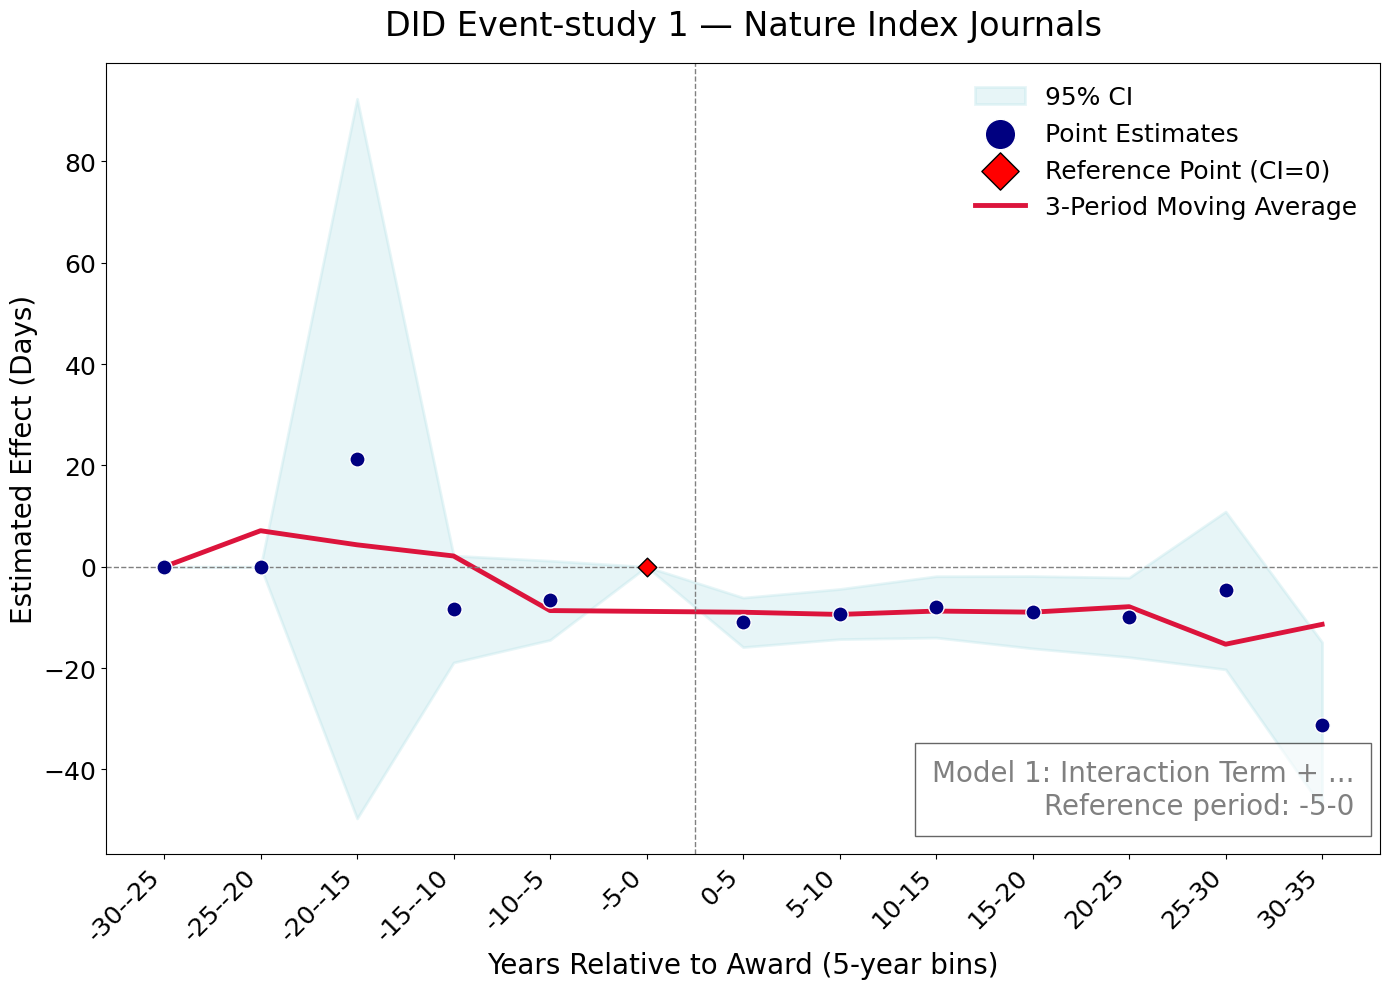

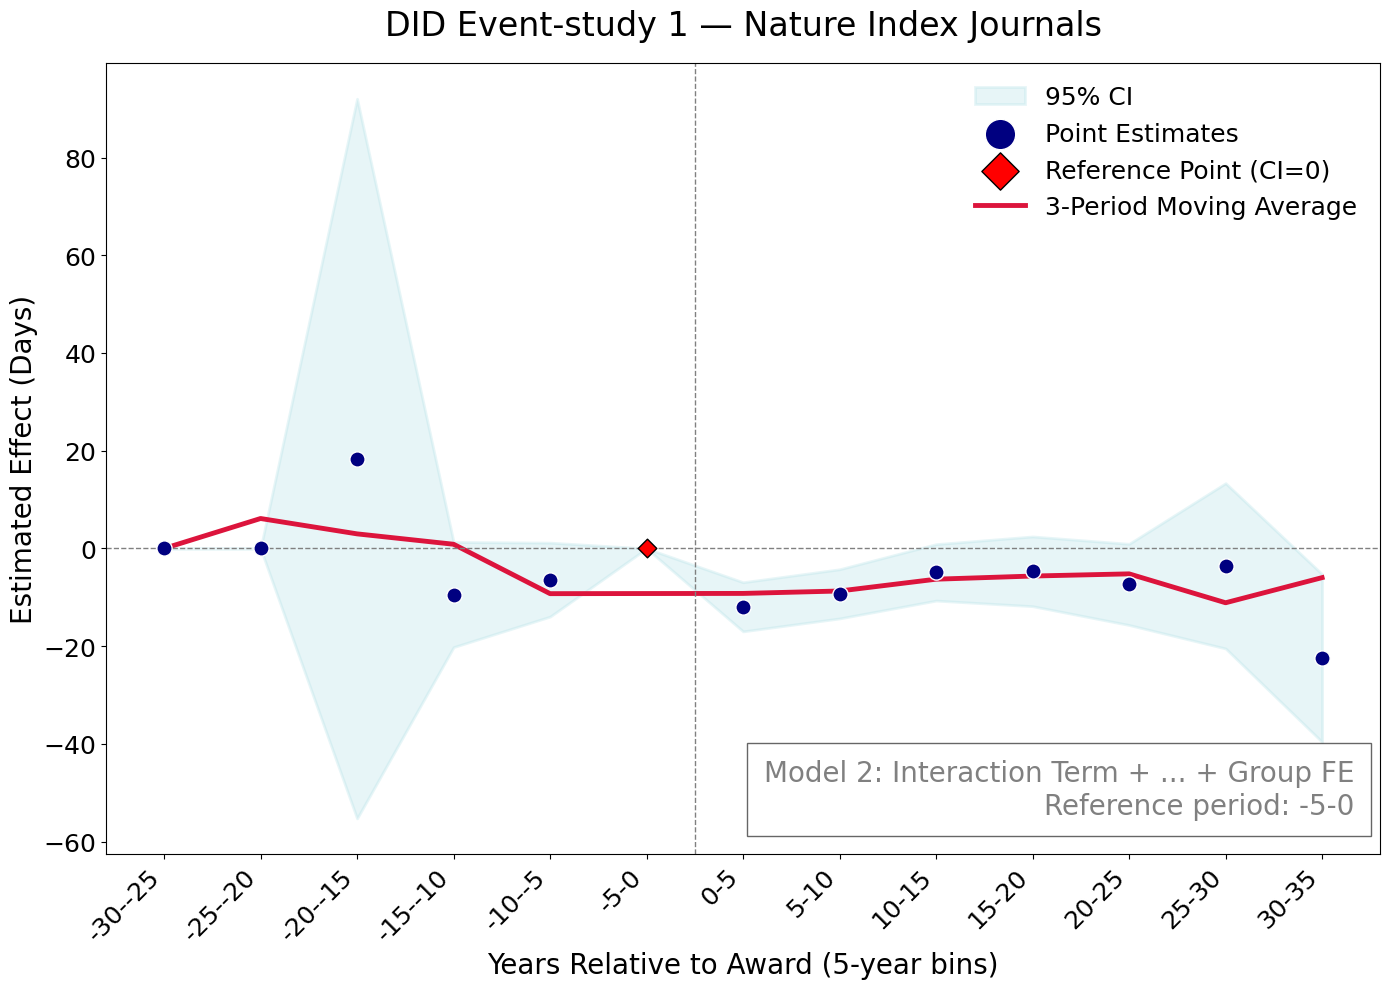


Processing Study 2A: Nature/Science/PNAS...
Details saved to: Study2A_Model1_Results.csv
Preview of Study2A_Model1_Results.csv:
                                  coef    std_err       p_value   ci_lower  \
C(JournalISSN)[T.1091-6490] -58.882849  11.273304  1.758467e-07 -80.978119   
C(JournalISSN)[T.1095-9203] -50.365745   7.682545  5.531948e-11 -65.423257   
C(JournalISSN)[T.1476-4687]  -1.852821   5.973562  7.564316e-01 -13.560788   
C(PubYear)[T.1979.0]         75.814465   7.276959  2.043042e-25  61.551887   
C(PubYear)[T.1990.0]          0.770179   8.774775  9.300579e-01 -16.428064   

                              ci_upper  
C(JournalISSN)[T.1091-6490] -36.787578  
C(JournalISSN)[T.1095-9203] -35.308233  
C(JournalISSN)[T.1476-4687]   9.855146  
C(PubYear)[T.1979.0]         90.077042  
C(PubYear)[T.1990.0]         17.968423  


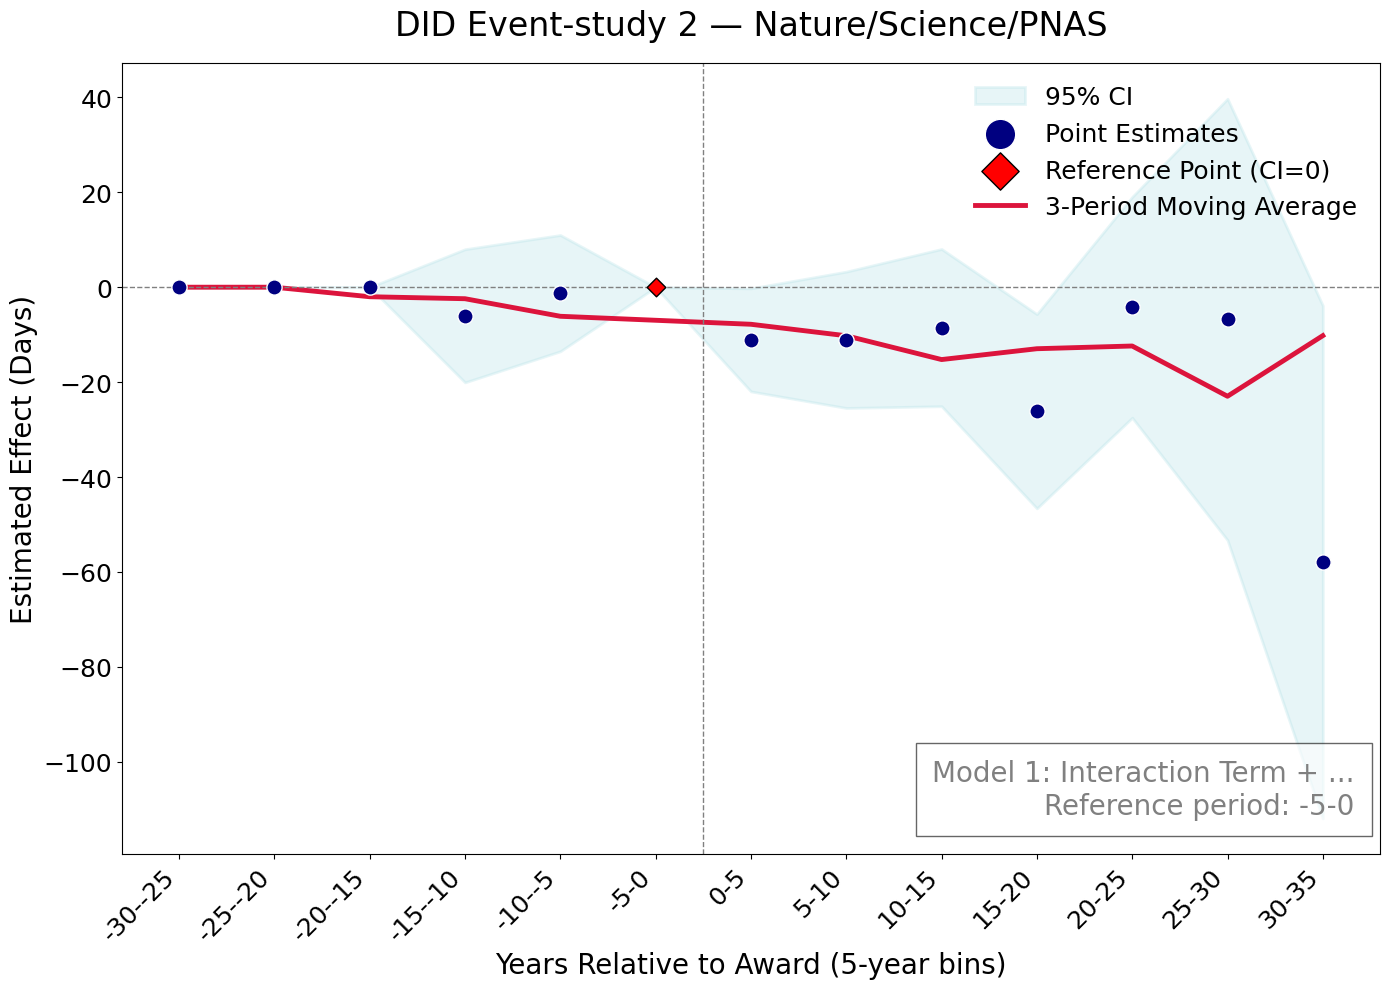

Details saved to: Study2A_Model2_Results.csv
Preview of Study2A_Model2_Results.csv:
                                  coef    std_err   p_value    ci_lower  \
C(JournalISSN)[T.1091-6490] -80.820296  20.046810  0.000055 -120.111321   
C(JournalISSN)[T.1095-9203] -37.553678   8.581153  0.000012  -54.372429   
C(JournalISSN)[T.1476-4687]   6.503312   7.232224  0.368539   -7.671587   
C(PubYear)[T.1979.0]         60.195256  33.911339  0.075885   -6.269748   
C(PubYear)[T.1990.0]        -18.528399  22.282525  0.405679  -62.201345   

                               ci_upper  
C(JournalISSN)[T.1091-6490]  -41.529271  
C(JournalISSN)[T.1095-9203]  -20.734927  
C(JournalISSN)[T.1476-4687]   20.678211  
C(PubYear)[T.1979.0]         126.660260  
C(PubYear)[T.1990.0]          25.144547  


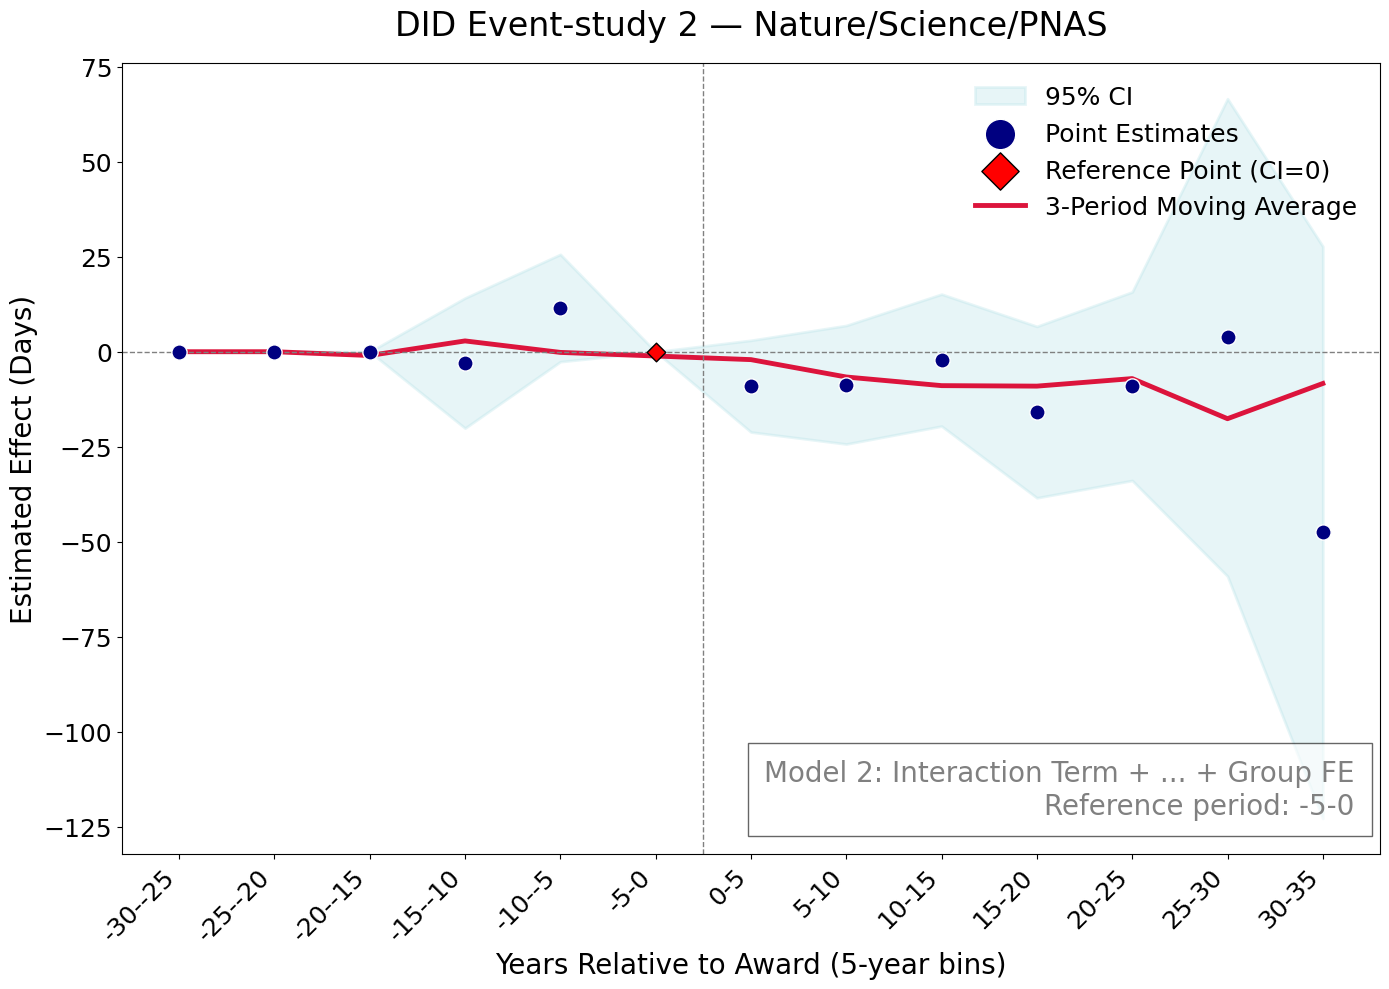


Processing Study 2B: Lancet/JAMA/NEJM/BMJ...
Details saved to: Study2B_Model1_Results.csv
Preview of Study2B_Model1_Results.csv:
                                  coef    std_err       p_value    ci_lower  \
C(JournalISSN)[T.1476-4687]  -0.678175   6.135202  9.119825e-01  -12.702949   
C(PubYear)[T.1979.0]         72.961959   7.859342  1.640478e-20   57.557932   
C(PubYear)[T.1990.0]          9.605026   9.344993  3.040317e-01   -8.710824   
C(PubYear)[T.1993.0]        -23.669835  47.006772  6.145840e-01 -115.801415   
C(PubYear)[T.1999.0]        -21.552304  19.932588  2.795816e-01  -60.619458   

                              ci_upper  
C(JournalISSN)[T.1476-4687]  11.346599  
C(PubYear)[T.1979.0]         88.365985  
C(PubYear)[T.1990.0]         27.920876  
C(PubYear)[T.1993.0]         68.461746  
C(PubYear)[T.1999.0]         17.514850  


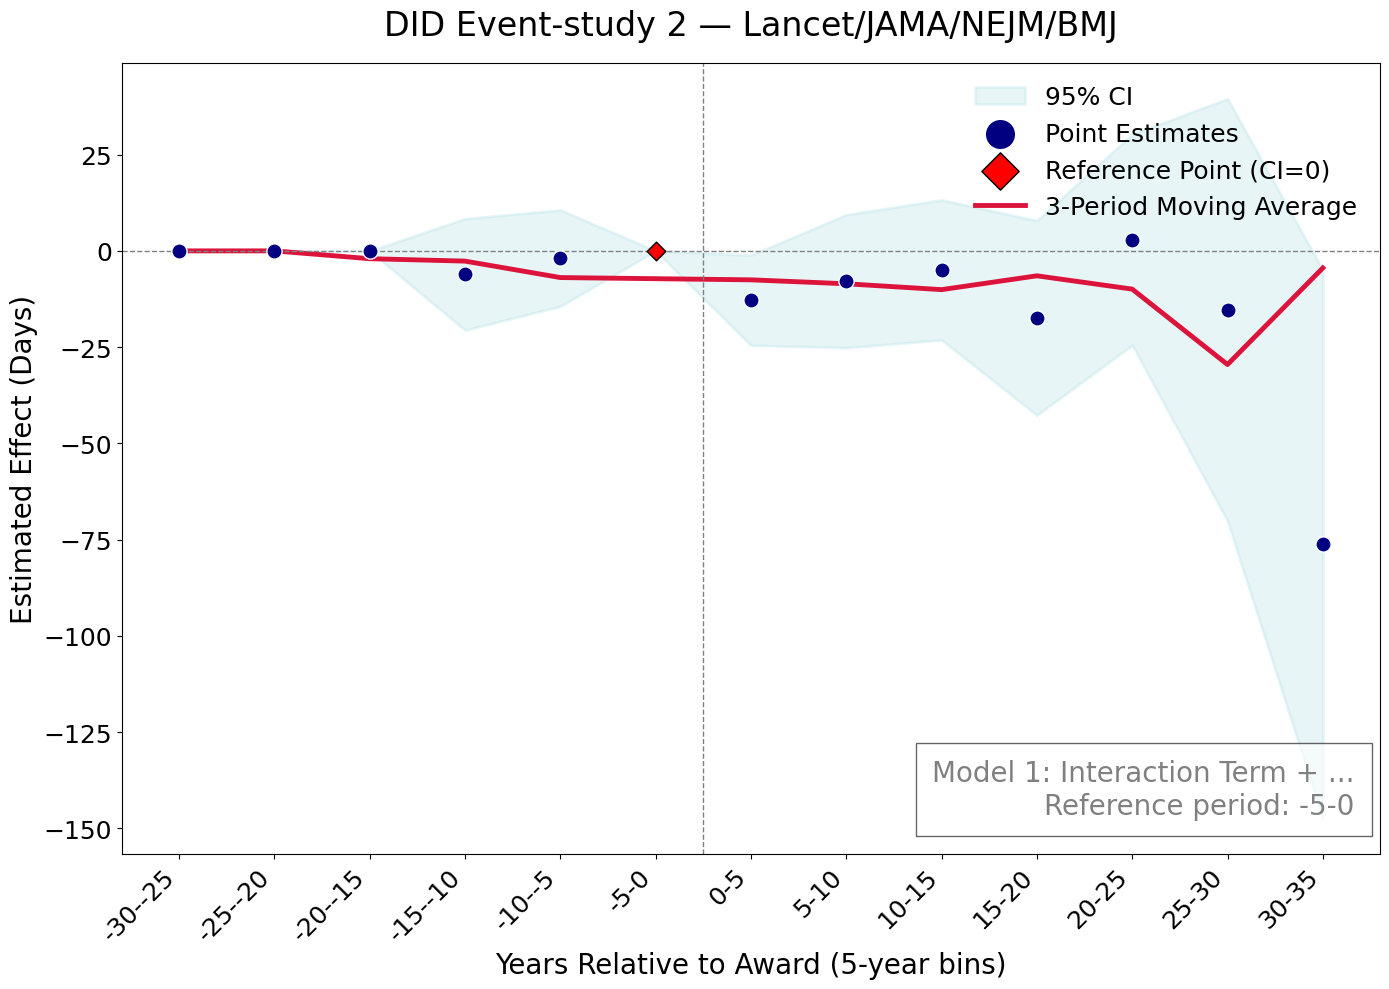

Details saved to: Study2B_Model2_Results.csv
Preview of Study2B_Model2_Results.csv:
                                  coef    std_err   p_value    ci_lower  \
C(JournalISSN)[T.1476-4687]   7.604567   7.451646  0.307481   -7.000391   
C(PubYear)[T.1979.0]         49.508133  41.433570  0.232134  -31.700172   
C(PubYear)[T.1990.0]        -31.814200  36.155040  0.378893 -102.676777   
C(PubYear)[T.1993.0]         17.810535  58.071257  0.759071  -96.007038   
C(PubYear)[T.1999.0]        -92.303691  34.933221  0.008235 -160.771545   

                               ci_upper  
C(JournalISSN)[T.1476-4687]   22.209525  
C(PubYear)[T.1979.0]         130.716438  
C(PubYear)[T.1990.0]          39.048377  
C(PubYear)[T.1993.0]         131.628108  
C(PubYear)[T.1999.0]         -23.835836  


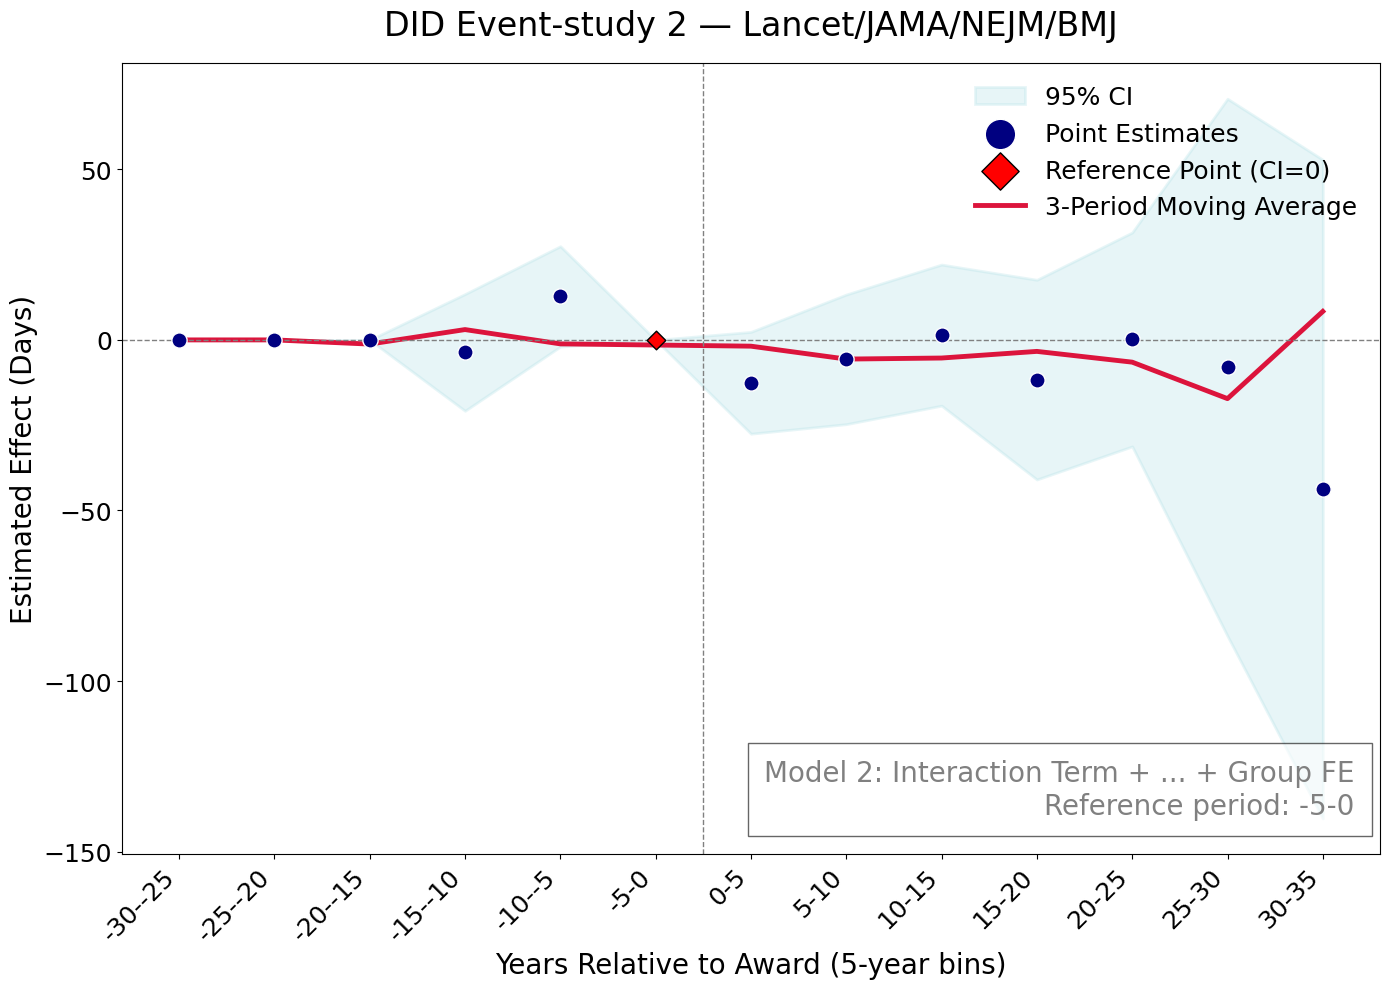


All plots generated and results saved successfully!


In [1]:
import pandas as pd
import sys
# sys.path.append('/home/ls2543/python_packages') 
import numpy as np
import re
import patsy
import statsmodels.api as sm
from joblib import load
import matplotlib.pyplot as plt

plt.rcParams.update({
    'axes.titlesize': 24,
    'axes.labelsize': 20,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 18,
    'legend.title_fontsize': 18,
    'figure.figsize': (14, 10)
})


df = pd.read_csv(
    '../../../final_group_pos_doipmid_puby_deltadays_field_tsize_top5_before0_after1_coauthor_wc0_natindex_fpy_aca_exp_jif_EISSN.csv',
    low_memory=False
)
df['is_nature_index'] = df['is_nature_index'].fillna(2).astype('category')
df['JournalISSN']      = df['JournalISSN'].fillna("Unknown")
df['author_position']  = pd.Categorical(df['author_position'], categories=["first","middle","last"])
df['field']            = df['field'].astype('category')
df['is_top5']          = df['is_top5'].astype('category')
df['before_or_after']  = df['before_or_after'].astype('category')
df['group_id']         = df['group_id'].astype(str).astype('category')

def save_model_results(model, filename):
    """
    Coef, Std.Err, t, P>|t|, [0.025, 0.975]
    """
    results_summary = pd.DataFrame({
        'coef': model.params,
        'std_err': model.bse,
        'p_value': model.pvalues,
        'ci_lower': model.conf_int()[0],
        'ci_upper': model.conf_int()[1]
    })
    
    results_summary.sort_index(inplace=True)
    
    results_summary.to_csv(filename)
    print(f"Details saved to: {filename}")
    
    print(f"Preview of {filename}:")
    print(results_summary.head()) 

def make_bins_and_labels(year_diff):
    mn = int(np.floor(year_diff.min()/5)*5)
    mx = int(np.ceil(year_diff.max()/5)*5)
    bins = list(range(mn, mx+5, 5))
    if 0 not in bins:
        bins.insert(np.searchsorted(bins, 0), 0)
    bins = sorted(bins)
    labels = []
    level_to_mid = {}
    reference_bin_label = None  

    for i in range(len(bins) - 1):
        left = bins[i]
        right = bins[i + 1]
    
        if left <= -1 < right:
            lab = f"{left}-{right}" 
            reference_bin_label = lab 
        else:
            lab = f"{left}-{right}"
        
        labels.append(lab)
        level_to_mid[lab] = (left + right) / 2
        
    return bins, labels, level_to_mid, reference_bin_label

def extract_plot_df(model, level_to_mid, ref_label):
    terms = [t for t in model.params.index if 'C(if_winner)[T.1]:C(year_diff_type)' in t]
    data = []
    ci = model.conf_int(0.05)
    for t in terms:
        m = re.search(r'C\(year_diff_type\)\[([^]]+)\]', t)
        if not m: continue
        lbl = m.group(1)
        if lbl == ref_label: continue  
        
        if lbl in level_to_mid:
            mid = level_to_mid[lbl]
        else:
            nums = re.findall(r'-?\d+', lbl)
            if len(nums) == 2:
                mid = (int(nums[0]) + int(nums[1])) / 2.0
            else:
                continue
        
        data.append({
            'term': t,
            'year_mid': mid,
            'label': lbl,
            'coef': model.params[t],
            'lower_ci': ci.loc[t, 0],
            'upper_ci': ci.loc[t, 1],
            'is_reference': False
        })
    
    if ref_label and ref_label in level_to_mid:
        ref_mid = level_to_mid[ref_label]
        data.append({
            'term': 'Reference',
            'year_mid': ref_mid,
            'label': ref_label,
            'coef': 0.0,
            'lower_ci': 0.0, 
            'upper_ci': 0.0, 
            'is_reference': True
        })
    
    dfp = pd.DataFrame(data).sort_values('year_mid')
    
    non_ref = dfp[~dfp['is_reference']].copy()
    if len(non_ref) > 0:
        non_ref['ma'] = non_ref['coef'].rolling(3, center=True, min_periods=1).mean()
    
    ref_points = dfp[dfp['is_reference']].copy()
    ref_points['ma'] = np.nan
    
    dfp = pd.concat([non_ref, ref_points]).sort_values('year_mid')
    return dfp

def plot_zoom(dfp, title, model_desc, ref_label, outname=None):
    fig, ax = plt.subplots(figsize=(14, 10))
    
    zoom = dfp[(dfp.year_mid >= -27.5) & (dfp.year_mid <= 32.5)].sort_values('year_mid')
    
    ref_points = zoom[zoom['is_reference']]
    non_ref_points = zoom[~zoom['is_reference']]
    
    ax.fill_between(zoom.year_mid, zoom.lower_ci, zoom.upper_ci,
                    linewidth=2, alpha=0.3, color='#B0E0E6', label='95% CI')

    ax.scatter(non_ref_points.year_mid, non_ref_points.coef, s=120, 
               color='navy', edgecolor='white', zorder=5, label='Point Estimates')
    
    if not ref_points.empty:
        ax.scatter(ref_points.year_mid, ref_points.coef, s=90,
                   color='red', marker='D', edgecolor='black', zorder=10, 
                   label='Reference Point (CI=0)')
    
    if not non_ref_points.empty and 'ma' in non_ref_points.columns:

        ax.plot(non_ref_points.year_mid, non_ref_points.ma, lw=3.5, color='crimson', 
                label=f'3-Period Moving Average')
    
    ax.axhline(0, color='gray', ls='--', lw=1)
    ax.axvline(0, color='gray', ls='--', lw=1)
    
    ax.set_title(title, fontsize=24, pad=20)
    ax.set_xlabel("Years Relative to Award (5-year bins)", fontsize=20)
    ax.set_ylabel("Estimated Effect (Days)", fontsize=20)
    
    ax.set_xticks(zoom.year_mid)
    ax.set_xticklabels(zoom.label, rotation=45, ha='right', fontsize=18)
    
    ax.legend(frameon=False, loc='upper right', fontsize=18, markerscale=2)
    
    display_ref_label = ref_label
    full_desc = f"{model_desc}\nReference period: {display_ref_label}"
    ax.text(0.98, 0.12, full_desc,
            transform=ax.transAxes,
            ha='right', va='top',
            fontsize=20,
            color='gray',
            bbox=dict(facecolor='white', alpha=0.6, pad=12))
    
    plt.tight_layout()
    if outname:
        plt.savefig(outname, dpi=300, bbox_inches='tight') 
    plt.show()

formula1 = '''
DeltaDays ~ 
C(if_winner):C(year_diff_type) + 
C(before_or_after) + 
C(is_top5) + 
JIF + teamsize + academic_experience + 
ref_num + cited_by_count + 
C(author_position) + C(JournalISSN) + 
C(field) + C(PubYear)
'''

formula2 = '''
DeltaDays ~ 
C(if_winner):C(year_diff_type) + 
C(before_or_after) + 
C(is_top5) + 
JIF + teamsize + academic_experience + 
ref_num + cited_by_count + 
C(author_position) + C(JournalISSN) + 
C(group_id) + C(PubYear)
'''

print("Processing Study 1: Nature Index Journals...")

df_nature = df[df['is_nature_index'] == 1].copy()
bins1, labels1, mid1, ref_label1 = make_bins_and_labels(df_nature['year_diff'])
df_nature['year_diff_type'] = pd.cut(df_nature['year_diff'], bins=bins1, labels=labels1, right=False)

if ref_label1 and ref_label1 in df_nature['year_diff_type'].cat.categories:
    df_nature['year_diff_type'] = df_nature['year_diff_type'].cat.remove_categories([ref_label1])

df_clean1 = df_nature.dropna(subset=[
    'DeltaDays', 'if_winner', 'year_diff_type', 'group_id',
    'JIF', 'teamsize', 'academic_experience', 'ref_num', 'cited_by_count'
])

# Model 1
y1, X1 = patsy.dmatrices(formula1, df_clean1, return_type='dataframe')
model1 = sm.OLS(y1, X1).fit(cov_type='cluster', cov_kwds={'groups': df_clean1['group_id']})
save_model_results(model1, 'Study1_Model1_Results.csv') 

# Model 2
y2, X2 = patsy.dmatrices(formula2, df_clean1, return_type='dataframe')
model2 = sm.OLS(y2, X2).fit(cov_type='cluster', cov_kwds={'groups': df_clean1['group_id']})
save_model_results(model2, 'Study1_Model2_Results.csv') 


plot_df1 = extract_plot_df(model1, mid1, ref_label1)
plot_zoom(plot_df1, 
          "DID Event-study 1 — Nature Index Journals",
          "Model 1: Interaction Term + ...",
          ref_label1,
          'DID_event_study1_model1_zoom.png')

plot_df2 = extract_plot_df(model2, mid1, ref_label1)
plot_zoom(plot_df2, 
          "DID Event-study 1 — Nature Index Journals",
          "Model 2: Interaction Term + ... + Group FE",
          ref_label1,
          'DID_event_study1_model2_zoom.png')

print("\nProcessing Study 2A: Nature/Science/PNAS...")
issn_a = {'0028-0836', '1476-4687', '0036-8075', '1095-9203', '0027-8424', '1091-6490'}
dfa = df[df['JournalISSN'].isin(issn_a)].copy()

bins2a, labels2a, mid2a, ref_label2a = make_bins_and_labels(dfa['year_diff'])
dfa['year_diff_type'] = pd.cut(dfa['year_diff'], bins=bins2a, labels=labels2a, right=False)

if ref_label2a and ref_label2a in dfa['year_diff_type'].cat.categories:
    dfa['year_diff_type'] = dfa['year_diff_type'].cat.remove_categories([ref_label2a])

df_clean2a = dfa.dropna(subset=[
    'DeltaDays', 'if_winner', 'year_diff_type', 'group_id',
    'JIF', 'teamsize', 'academic_experience', 'ref_num', 'cited_by_count'
])

# MODEL 1
y1, X1 = patsy.dmatrices(formula1, df_clean2a, return_type='dataframe')
model2a1 = sm.OLS(y1, X1).fit(cov_type='cluster', cov_kwds={'groups': df_clean2a['group_id']})
save_model_results(model2a1, 'Study2A_Model1_Results.csv') 
plot_df2a1 = extract_plot_df(model2a1, mid2a, ref_label2a)
plot_zoom(plot_df2a1, 
          "DID Event-study 2 — Nature/Science/PNAS",
          "Model 1: Interaction Term + ...",
          ref_label2a,
          'DID_event_study2a_model1_zoom.png')

# MODEL 2
y2, X2 = patsy.dmatrices(formula2, df_clean2a, return_type='dataframe')
model2a2 = sm.OLS(y2, X2).fit(cov_type='cluster', cov_kwds={'groups': df_clean2a['group_id']})
save_model_results(model2a2, 'Study2A_Model2_Results.csv') 
plot_df2a2 = extract_plot_df(model2a2, mid2a, ref_label2a)
plot_zoom(plot_df2a2, 
          "DID Event-study 2 — Nature/Science/PNAS",
          "Model 2: Interaction Term + ... + Group FE",
          ref_label2a,
          'DID_event_study2a_model2_zoom.png')


print("\nProcessing Study 2B: Lancet/JAMA/NEJM/BMJ...")
issn_b = {'0028-0836', '1476-4687', '0098-7484', '1538-3598', '0028-4793', '1533-4406', '0959-8138', '1756-1833'}
dfb = df[df['JournalISSN'].isin(issn_b)].copy()

bins2b, labels2b, mid2b, ref_label2b = make_bins_and_labels(dfb['year_diff'])
dfb['year_diff_type'] = pd.cut(dfb['year_diff'], bins=bins2b, labels=labels2b, right=False)

if ref_label2b and ref_label2b in dfb['year_diff_type'].cat.categories:
    dfb['year_diff_type'] = dfb['year_diff_type'].cat.remove_categories([ref_label2b])

df_clean2b = dfb.dropna(subset=[
    'DeltaDays', 'if_winner', 'year_diff_type', 'group_id',
    'JIF', 'teamsize', 'academic_experience', 'ref_num', 'cited_by_count'
])

# MODEL 1
y1b, X1b = patsy.dmatrices(formula1, df_clean2b, return_type='dataframe')
model2b1 = sm.OLS(y1b, X1b).fit(cov_type='cluster', cov_kwds={'groups': df_clean2b['group_id']})
save_model_results(model2b1, 'Study2B_Model1_Results.csv') 
plot_df2b1 = extract_plot_df(model2b1, mid2b, ref_label2b)
plot_zoom(plot_df2b1, 
          "DID Event-study 2 — Lancet/JAMA/NEJM/BMJ",
          "Model 1: Interaction Term + ...",
          ref_label2b,
          'DID_event_study2b_model1_zoom.png')

# MODEL 2
y2b, X2b = patsy.dmatrices(formula2, df_clean2b, return_type='dataframe')
model2b2 = sm.OLS(y2b, X2b).fit(cov_type='cluster', cov_kwds={'groups': df_clean2b['group_id']})
save_model_results(model2b2, 'Study2B_Model2_Results.csv') 
plot_df2b2 = extract_plot_df(model2b2, mid2b, ref_label2b)
plot_zoom(plot_df2b2, 
          "DID Event-study 2 — Lancet/JAMA/NEJM/BMJ",
          "Model 2: Interaction Term + ... + Group FE",
          ref_label2b,
          'DID_event_study2b_model2_zoom.png')

print("\nAll plots generated and results saved successfully!")